In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ibm = ["#ffb000", "#fe6100", "#dc267f", "#785ef0", "#648fff"]

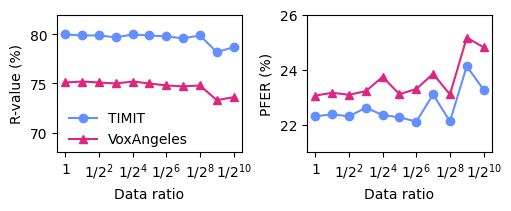

In [ ]:
# Sample efficiency plot

ratio = [f"1/{2 ** i}" for i in range(11)]

timit_rv        = [0.800, 0.799, 0.799, 0.797, 0.800, 0.799, 0.798, 0.796, 0.799, 0.782, 0.787]
timit_pfer      = [0.2230, 0.2238, 0.2230, 0.2262, 0.2235, 0.2227, 0.2211, 0.2310, 0.2212, 0.2413, 0.2327]
voxangeles_rv   = [0.751, 0.752, 0.751, 0.750, 0.752, 0.750, 0.748, 0.747, 0.748, 0.733, 0.736]
voxangeles_pfer = [0.2306, 0.2316, 0.2309, 0.2322, 0.2374, 0.2311, 0.2330, 0.2385, 0.2310, 0.2517, 0.2482]

fig, axes = plt.subplots(1, 2, figsize=(5, 2), layout="constrained")
axes[0].plot([x * 100 for x in timit_rv], "o-", label="TIMIT", c=ibm[4], markersize=6)
axes[0].plot([x * 100 for x in voxangeles_rv], "^-", label="VoxAngeles", c=ibm[2], markersize=6)
axes[0].set_xlabel("Data ratio")
axes[0].set_xticks(list(range(len(ratio)))[::2])
axes[0].set_xticklabels(["$1$", "$1/2^2$", "$1/2^4$", "$1/2^6$", "$1/2^8$", "$1/2^{10}$"])
axes[0].set_ylabel("R-value (%)")
axes[0].legend(loc="lower left", frameon=False, bbox_to_anchor=(0, -0.05))
axes[0].set_ylim(68, 82)

axes[1].plot([x * 100 for x in timit_pfer], "o-", label="TIMIT", c=ibm[4], markersize=6)
axes[1].plot([x * 100 for x in voxangeles_pfer], "^-", label="VoxAngeles", c=ibm[2], markersize=6)
axes[1].set_xlabel("Data ratio")
axes[1].set_xticks(list(range(len(ratio)))[::2])
axes[1].set_xticklabels(["$1$", "$1/2^2$", "$1/2^4$", "$1/2^6$", "$1/2^8$", "$1/2^{10}$"])
# axes[1].set_xticklabels(ratio)
# axes[1].tick_params(axis="x", rotation=90)
axes[1].set_ylabel("PFER (%)")
axes[1].set_ylim(21, 26)

plt.savefig("plots/efficiency.pdf", bbox_inches="tight", pad_inches=0.0)

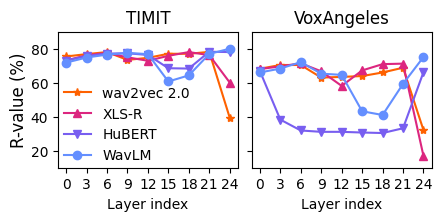

In [ ]:
layer = [0, 3, 6, 9, 12, 15, 18, 21, 24]
timit = {
    "wav2vec 2.0": [0.754, 0.768, 0.780, 0.734, 0.746, 0.770, 0.770, 0.781, 0.394],
    "XLS-R":       [0.731, 0.761, 0.775, 0.749, 0.729, 0.758, 0.780, 0.762, 0.601],
    "HuBERT":      [0.730, 0.757, 0.771, 0.773, 0.763, 0.685, 0.683, 0.782, 0.780],
    "WavLM":       [0.718, 0.748, 0.765, 0.775, 0.768, 0.607, 0.643, 0.769, 0.800],
}

voxangeles = {
    "wav2vec 2.0": [0.682, 0.704, 0.704, 0.630, 0.634, 0.639, 0.660, 0.688, 0.321],
    "XLS-R":       [0.680, 0.696, 0.714, 0.667, 0.581, 0.672, 0.709, 0.712, 0.169],
    "HuBERT":      [0.669, 0.383, 0.319, 0.311, 0.311, 0.307, 0.304, 0.332, 0.662],
    "WavLM":       [0.660, 0.683, 0.721, 0.653, 0.646, 0.432, 0.410, 0.593, 0.751],
}
markers = ["*", "^", "v", "o"]


fig, axes = plt.subplots(1, 2, figsize=(4.1, 2.1), sharey=True, layout="constrained")
axes[0].set_ylim(10, 90)
axes[0].set_yticks([20, 40, 60, 80])

for ax, name, data in zip(axes, ["TIMIT", "VoxAngeles"], [timit, voxangeles]):
    ax.set_title(name)
    for i, (marker, (model, value)) in enumerate(zip(markers, data.items())):
        ax.plot([v * 100 for v in value], f"{marker}-", label=model, c=ibm[i+1])
    ax.set_xticks(list(range(len(layer))))
    ax.set_xticklabels(layer)
    ax.set_xlabel("Layer index")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower left", bbox_to_anchor=(0.06, 0.19), frameon=False)
fig.supylabel("R-value (%)", x=-0.04, y=0.55)
plt.savefig("plots/layerwise.pdf", bbox_inches="tight", pad_inches=0.0)